In [15]:
import pandas as pd
import matplotlib.pyplot as plt


          data  aeroporto       fiera
0   2025-03-01  11.898493   57.314352
1   2025-03-02  12.190898   58.357870
2   2025-03-03  13.906398   67.268056
3   2025-03-04  12.280733   75.725810
4   2025-03-05  11.969858  107.874595
..         ...        ...         ...
118 2025-09-26  13.070700   64.362269
119 2025-09-27  12.884752   40.171181
120 2025-09-28  12.722961   37.002315
121 2025-09-29  13.415189   48.592477
122 2025-09-30  11.975855   51.080087

[123 rows x 3 columns]


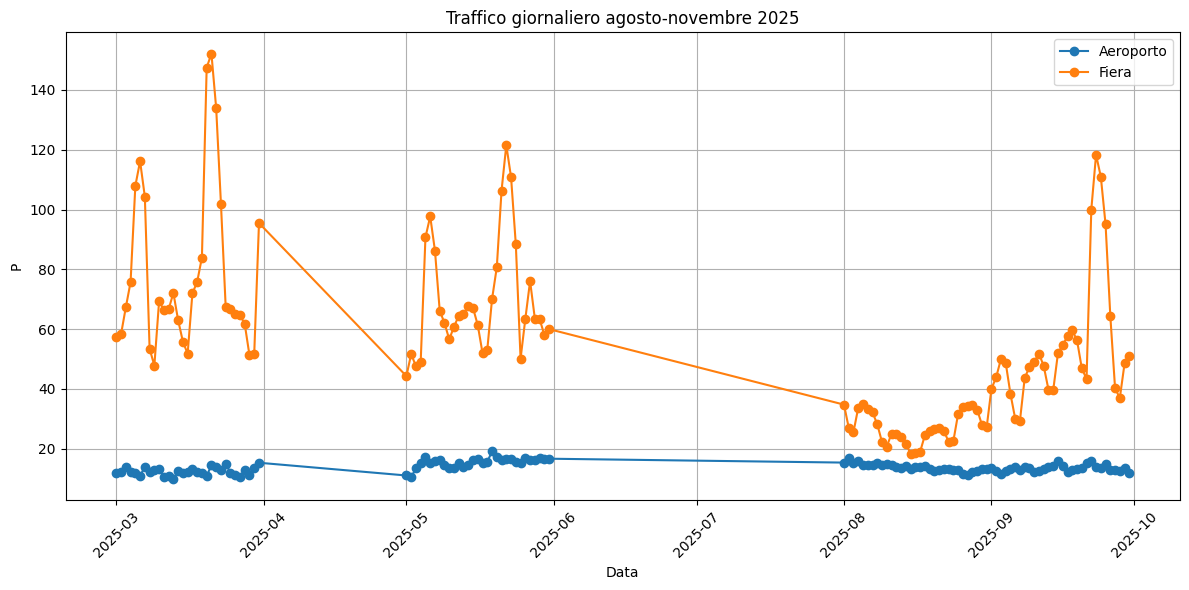

In [16]:
import pandas as pd

# 1️⃣ Mappa mese → file CSV
month_files = {
    3: 'marzo_daily_avg_per_zone.csv',
    5: 'maggio_daily_avg_per_zone.csv',
    8: 'agosto_daily_avg_per_zone.csv',
    9: 'settembre_daily_avg_per_zone.csv'
}

# 2️⃣ Lista per contenere DataFrame dei singoli mesi
dfs = []

for month, file in month_files.items():
    # Leggi CSV (modifica sep se necessario)
    df = pd.read_csv(file, sep=',')  # oppure sep='\t' se tab-separated

    # Normalizza nomi colonne
    df.columns = df.columns.str.strip()

    # Crea colonna 'data' a partire da 'Numero_Giorno' e mese corrente
    df['data'] = pd.to_datetime(f'2025-{month:02d}-01') + pd.to_timedelta(df['Numero_Giorno'] - 1, unit='d')

    dfs.append(df)

# 3️⃣ Unisci tutti i DataFrame
df_all = pd.concat(dfs, ignore_index=True)

# 4️⃣ Trasforma in wide format (data, aeroporto, fiera)
df_wide = df_all.pivot(index='data', columns='Zona', values='P').reset_index()
df_wide.columns.name = None
df_wide = df_wide.rename(columns={'Aeroporto':'aeroporto', 'Fiera':'fiera'})

# 5️⃣ Controlla risultato
print(df_wide)

# Salva in CSV
df_wide.to_csv('traffico_aeroporto_fiera.csv', index=False)

# 6️⃣ Grafico (opzionale)
plt.figure(figsize=(12,6))
plt.plot(df_wide['data'], df_wide['aeroporto'], label='Aeroporto', marker='o')
plt.plot(df_wide['data'], df_wide['fiera'], label='Fiera', marker='o')
plt.xlabel('Data')
plt.ylabel('P')
plt.title('Traffico giornaliero agosto-novembre 2025')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
